In [2]:
import velot
import scanpy as sc

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
adata = sc.read_h5ad("results/data/velot_seed0_smooth_erythroid.h5ad")
adata

AnnData object with n_obs × n_vars = 9815 × 14352
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'n_counts', 'clusters_id', 'dpt_pseudotime', 'pseudotime', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'n_cells'
    uns: 'celltype_colors', 'diffmap_evals', 'iroot', 'neighbors', 'velot_raw_velocity_params', 'velot_root', 'velot_smoothing', 'velot_windows'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'velot_velocity_pca', 'velot_velocity_raw_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

## Trajectories for cluster Alpha

In [4]:
start_cluster = "Blood progenitors 1"
n_trajectories = 15

velot.tl.compute_trajectories(
    adata,
    basis=f"X_pca",
    velocity_key=f"velot_velocity_pca",
    direction="forward",
    use_network=False,
    evolve_pseudotime=True,
    start_cluster=start_cluster,
    n_trajectories=n_trajectories,
    cluster_key="celltype",
    n_steps=300, step_size=2
)

Found torch compatible version. Running on cuda device
  Starting cells: 623 candidates (cluster='Blood progenitors 1')
  Total: 15 trajectories (forward) from 'Blood progenitors 1'
  Forward — Terminal clusters: {np.str_('Erythroid3'): np.int64(15)}


AnnData object with n_obs × n_vars = 9815 × 14352
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'n_counts', 'clusters_id', 'dpt_pseudotime', 'pseudotime', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'n_cells'
    uns: 'celltype_colors', 'diffmap_evals', 'iroot', 'neighbors', 'velot_raw_velocity_params', 'velot_root', 'velot_smoothing', 'velot_windows', 'velot_trajectories'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'velot_velocity_pca', 'velot_velocity_raw_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

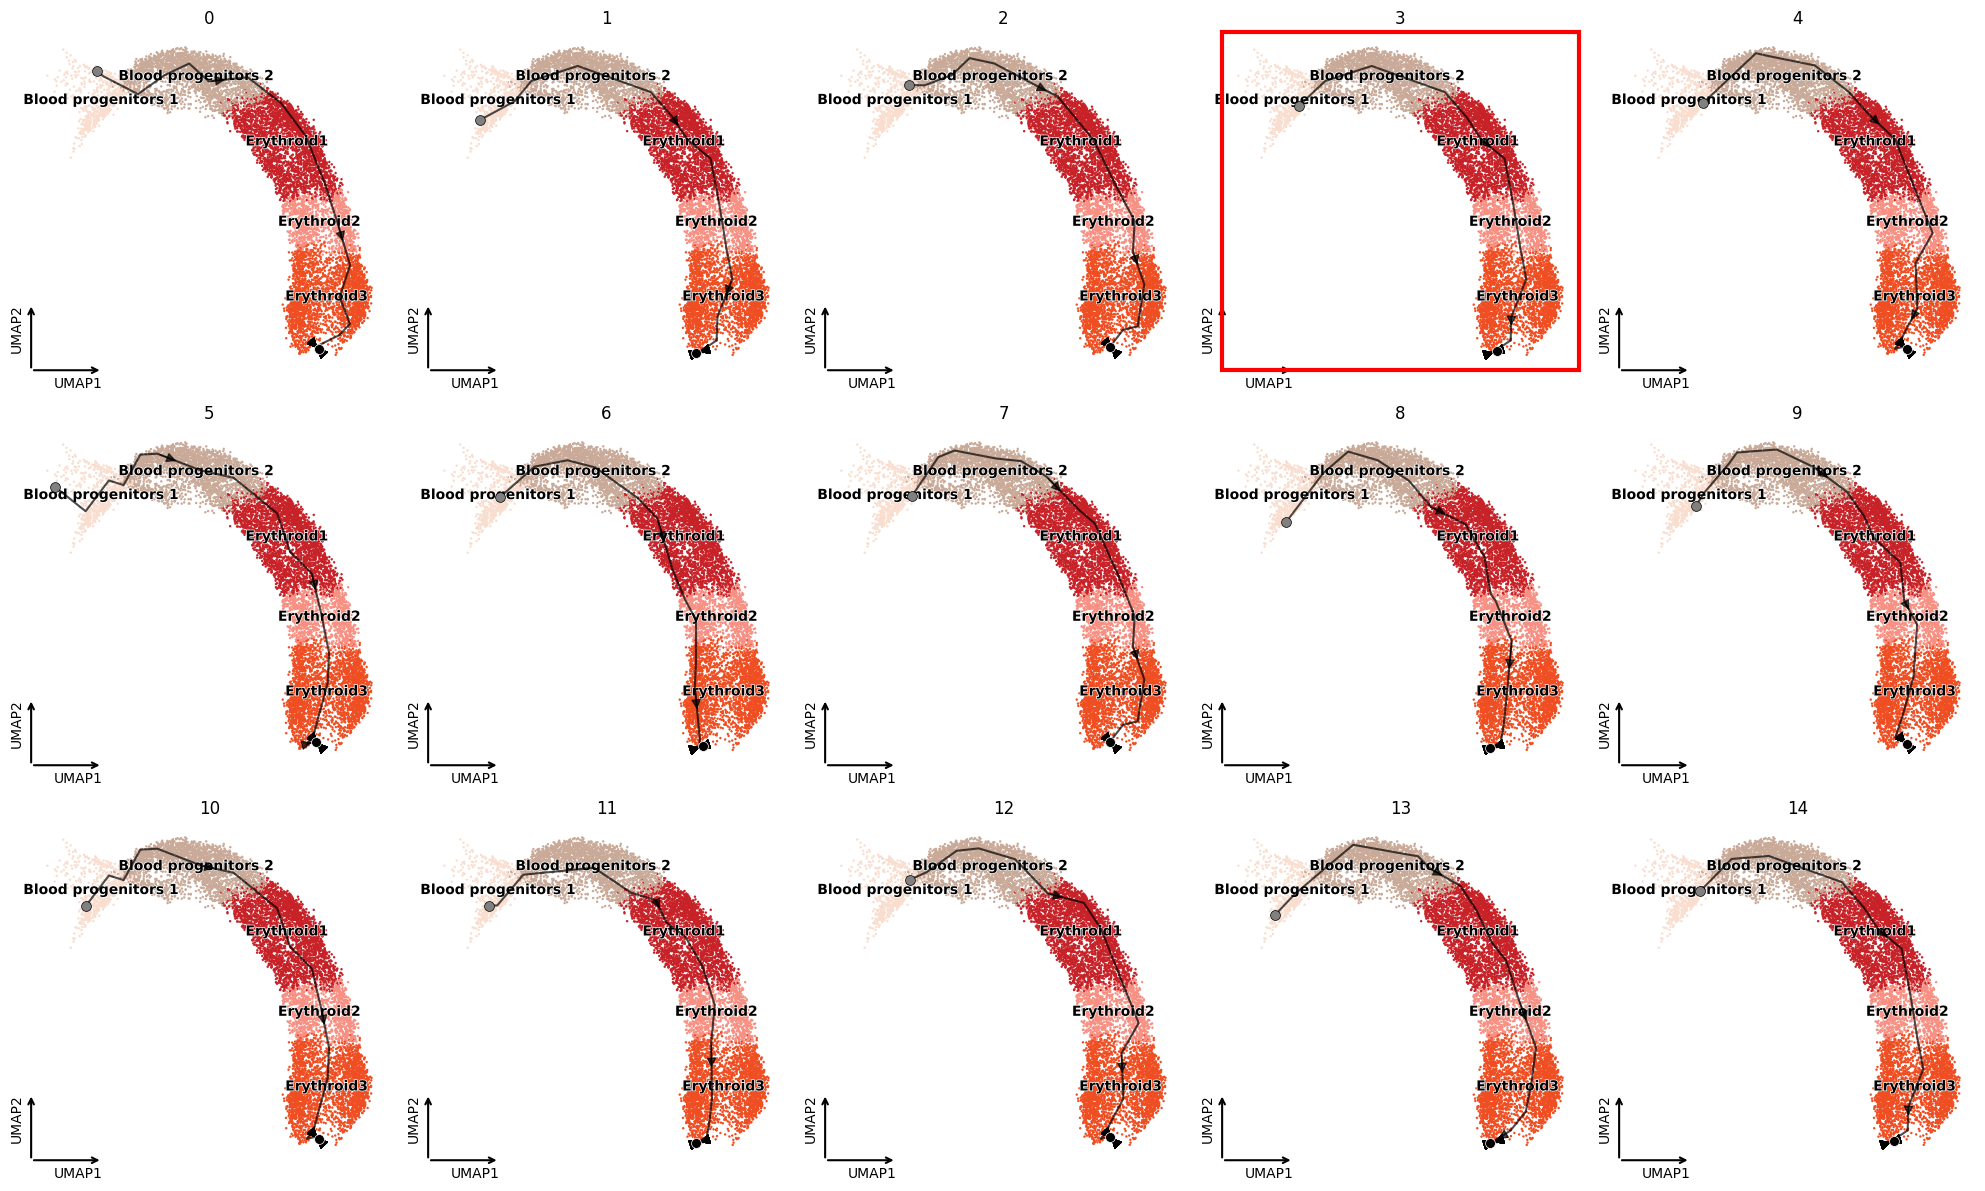

<Axes: >

In [8]:
n_cols = 5
n_rows = (n_trajectories + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()
for i in range(n_trajectories):
    velot.pl.trajectories(
        adata, color="celltype", trajectory_ids=[i], line_width=1.5, line_style="-", arrow_frequency=5, arrow_size=15,
        basis="umap", show=False, save=False, figsize=(5,5), ax = axes[i], title=i
    )
axes[3].add_patch(
    patches.Rectangle(
        (0, 0), 1, 1,            # Use (-0.03, -0.03), 1.06, 1.06 for outer padding
        transform=axes[3].transAxes,
        fill=False,
        edgecolor="red",
        linewidth=3,
        clip_on=False,           # Prevents the border from being clipped at the edges
        zorder=101
    )
)
for ax in axes[n_trajectories:]:
    ax.remove()
plt.tight_layout()
plt.show()

velot.pl.trajectories(
    adata, color="celltype", trajectory_ids=[3], line_width=1.5, line_style="-", arrow_frequency=5, arrow_size=15,
    basis="umap", show=False, save=True, save_path=f"figure4_i.png"
)